<a href="https://colab.research.google.com/github/scudilio/MBA---Deep-Learning/blob/main/DeepLearning_Aula01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Deep Learning — Aula 01: Fundamentos e Redes Neurais
### MBA em Ciência de Dados · FIAP

---

##  Problema de Negócio: Previsão de Churn em Telecom

Uma operadora de telecomunicações enfrenta um problema crítico:  
**22% dos clientes cancelam o plano todo mês**, representando **R\$132 milhões em receita perdida por ano**.

Os modelos de regras falharam. Regressão Logística chegou a 67% de acurácia.  
Hoje vamos construir, do zero ao deploy, uma **Rede Neural Profunda (MLP)** para resolver isso.

### Ao longo deste notebook você vai aprender:

| Conceito | O que veremos |
|---|---|
| Perceptron | Implementação manual |
| MLP (Feedforward) | Construção com Keras |
| Backpropagation | Visualização dos gradientes |
| Funções de Ativação | Comparação prática |
| Learning Rate | Impacto nas curvas de loss |
| Overfitting | Detecção e diagnóstico |
| Regularização L1/L2 | Efeito nos pesos |
| Dropout | Comparação com/sem |
| Early Stopping | Implementação completa |

---
##  0. Setup e Dependências

In [1]:
# ── Instalação (execute apenas uma vez) ────────────────────────────────────────
# !pip install tensorflow scikit-learn pandas numpy matplotlib seaborn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)

# Reprodutibilidade
np.random.seed(42)
tf.random.set_seed(42)

# Estilo FIAP
plt.style.use('dark_background')
MAGENTA  = '#EC008C'
CYAN     = '#00C8FF'
YELLOW   = '#FFD700'
GREEN    = '#00E676'
RED      = '#FF4444'
GRAY     = '#A0A0C0'
BG_CARD  = '#1E1E3A'

print(f'✅ TensorFlow {tf.__version__} carregado com sucesso!')
print(f'✅ GPU disponível: {len(tf.config.list_physical_devices("GPU")) > 0}')

✅ TensorFlow 2.19.0 carregado com sucesso!
✅ GPU disponível: False


---
##  1. Coleta do Dataset de Negócio


### Features do Cliente:
- **Comportamentais**: uso de dados, minutos de ligação, chamadas ao suporte
- **Contratuais**: tipo de plano, tempo de contrato, método de pagamento
- **Financeiras**: mensalidade, atraso em pagamentos, desconto ativo
- **Demográficas**: idade estimada, região, tem dependentes

> ! **Importante:** O dataset tem **desbalanceamento** — apenas ~22% de churners, refletindo a realidade do negócio.

In [3]:
url = 'https://raw.githubusercontent.com/scudilio/MBA---Deep-Learning/refs/heads/main/churn_telecom.csv'
df = pd.read_csv(url)
df.head()

,uso_dados_gb,minutos_voz,chamadas_suporte,num_produtos,tempo_contrato_meses,tipo_plano,metodo_pagamento,mensalidade_reais,atraso_pagamento_dias,tem_desconto,idade,regiao,tem_dependentes,nps_score,churn
0,25.63,81,10,4,11,1,0,148.65,0,1,57,0,0,-1,0
1,8.74,800,1,4,61,1,2,141.90,0,0,46,3,0,-1,0
2,36.61,800,2,2,41,2,0,94.77,0,0,62,3,1,9,0
3,42.63,136,1,1,59,1,0,91.08,0,1,74,2,1,-1,0
4,4.22,750,2,2,43,1,1,125.28,1,1,51,0,0,4,0


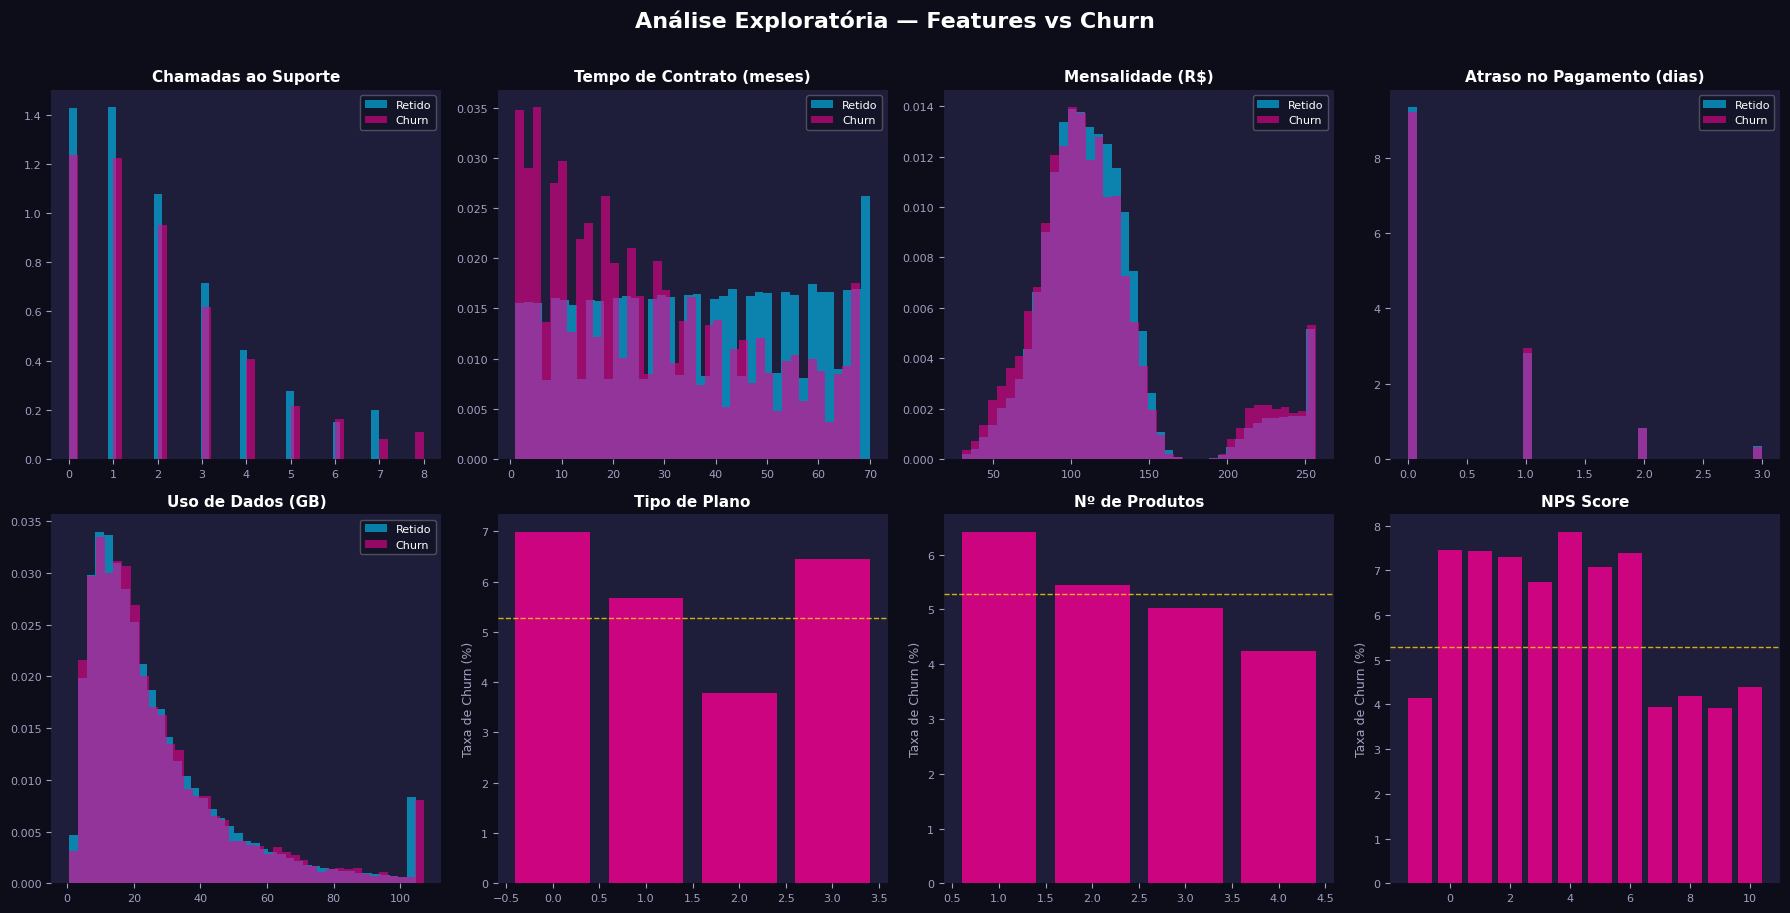

💡 Insights: chamadas ao suporte e tipo_plano pré-pago são os principais sinais de churn!


In [4]:
# ── Análise Exploratória Visual ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Análise Exploratória — Features vs Churn',
             fontsize=16, color='white', fontweight='bold', y=1.01)
fig.patch.set_facecolor('#0D0D1A')

features_plot = [
    ('chamadas_suporte',     'Chamadas ao Suporte',    False),
    ('tempo_contrato_meses', 'Tempo de Contrato (meses)', False),

    ('mensalidade_reais',    'Mensalidade (R$)',         False),
    ('atraso_pagamento_dias','Atraso no Pagamento (dias)', False),
    ('uso_dados_gb',         'Uso de Dados (GB)',        False),
    ('tipo_plano',           'Tipo de Plano',            True),
    ('num_produtos',         'Nº de Produtos',           True),
    ('nps_score',            'NPS Score',                True),
]

for ax, (feat, label, is_cat) in zip(axes.flat, features_plot):
    ax.set_facecolor(BG_CARD)

    churners = df[df.churn == 1][feat]
    retidos  = df[df.churn == 0][feat]

    if is_cat:
        cats = sorted(df[feat].unique())
        churn_rate = df.groupby(feat)['churn'].mean()
        bars = ax.bar(cats, churn_rate.values * 100,
                      color=MAGENTA, alpha=0.85, edgecolor='none')
        ax.set_ylabel('Taxa de Churn (%)', color=GRAY, fontsize=9)
        ax.axhline(df.churn.mean() * 100, color=YELLOW,
                   linestyle='--', linewidth=1, alpha=0.8, label='Média')
    else:
        ax.hist(retidos.clip(upper=retidos.quantile(0.98)), bins=40,
                alpha=0.6, color=CYAN, label='Retido', density=True)
        ax.hist(churners.clip(upper=churners.quantile(0.98)), bins=40,
                alpha=0.6, color=MAGENTA, label='Churn', density=True)
        ax.legend(fontsize=8, framealpha=0.3)

    ax.set_title(label, color='white', fontsize=11, fontweight='bold')
    ax.tick_params(colors=GRAY, labelsize=8)
    for spine in ax.spines.values(): spine.set_visible(False)

plt.tight_layout()
plt.savefig('/tmp/eda.png', dpi=100, bbox_inches='tight', facecolor='#0D0D1A')
plt.show()
print('💡 Insights: chamadas ao suporte e tipo_plano pré-pago são os principais sinais de churn!')

---
## 2. O Perceptron — Implementação do Zero

Antes de usar bibliotecas, vamos entender como um único neurônio funciona.

### O Perceptron resolve:
```
Dado: x = [chamadas_suporte, tempo_contrato]
Pergunta: este cliente vai churnar?

z = w₁ × chamadas_suporte + w₂ × tempo_contrato + b
ŷ = 1 se z ≥ 0  (churna)
ŷ = 0 se z < 0  (fica)
```

> ⚠️ **Limitação importante:** O perceptron só funciona para problemas **linearmente separáveis**.  
> Clientes de churn não são linearmente separáveis no mundo real — daí precisamos de MLP!

In [ ]:
class Perceptron:
    """
    Implementação manual do Perceptron para fins didáticos.
    Treinado com a Regra de Aprendizado do Perceptron (Rosenblatt, 1957).
    """

    def __init__(self, n_features: int, learning_rate: float = 0.01):
        # Inicialização dos pesos com pequenos valores aleatórios
        self.w  = np.random.randn(n_features) * 0.01  # pesos
        self.b  = 0.0                                  # bias
        self.lr = learning_rate
        self.historico_erros = []

    def _step_function(self, z: float) -> int:
        """Função de ativação degrau: 1 se z ≥ 0, senão 0."""
        return 1 if z >= 0 else 0

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Feedforward: z = X @ w + b → ativação"""
        z = X @ self.w + self.b          # soma ponderada (produto escalar)
        return np.array([self._step_function(zi) for zi in z])

    def fit(self, X: np.ndarray, y: np.ndarray, epochs: int = 20):
        """Treino com a regra do Perceptron: w ← w + η(y - ŷ)x"""
        n_samples = X.shape[0]

        for epoch in range(epochs):
            erros = 0

            for xi, yi in zip(X, y):        # para cada exemplo
                yi_hat = self._step_function(xi @ self.w + self.b)
                erro   = yi - yi_hat         # diferença entre real e predito

                if erro != 0:                # só atualiza se errou
                    # REGRA DE ATUALIZAÇÃO DO PERCEPTRON
                    # w ← w + η × erro × x
                    self.w += self.lr * erro * xi
                    self.b += self.lr * erro
                    erros += 1

            taxa_erro = erros / n_samples
            self.historico_erros.append(taxa_erro)

            if (epoch + 1) % 5 == 0:
                print(f'  Época {epoch+1:3d} | Taxa de Erro: {taxa_erro:.4f} | '
                      f'Erros: {erros:,}')

        return self

    def accuracy(self, X: np.ndarray, y: np.ndarray) -> float:
        return (self.predict(X) == y).mean()


# ── Preparar dados para o Perceptron (apenas 2 features + amostra menor) ──────
# Usando apenas 2 features para poder visualizar o espaço 2D
X_perc = df[['chamadas_suporte', 'tempo_contrato_meses']].values.astype(float)
y_perc = df['churn'].values

# Normalização manual (z-score)
X_perc = (X_perc - X_perc.mean(axis=0)) / X_perc.std(axis=0)

# Amostra balanceada para treinar
idx_churn  = np.where(y_perc == 1)[0][:3000]
idx_retido = np.where(y_perc == 0)[0][:3000]
idx = np.concatenate([idx_churn, idx_retido])
np.random.shuffle(idx)

X_tr = X_perc[idx]
y_tr = y_perc[idx]

print('=' * 55)
print('🧠  TREINANDO PERCEPTRON')
print('   Features: chamadas_suporte + tempo_contrato')
print('=' * 55)

perceptron = Perceptron(n_features=2, learning_rate=0.1)
perceptron.fit(X_tr, y_tr, epochs=20)

print(f'\n📊 Acurácia Final: {perceptron.accuracy(X_tr, y_tr):.4f}')
print(f'   Pesos:  w₁={perceptron.w[0]:.4f}  w₂={perceptron.w[1]:.4f}')
print(f'   Bias:   b={perceptron.b:.4f}')

🧠  TREINANDO PERCEPTRON
   Features: chamadas_suporte + tempo_contrato
  Época   5 | Taxa de Erro: 0.4780 | Erros: 2,868
  Época  10 | Taxa de Erro: 0.4767 | Erros: 2,860
  Época  15 | Taxa de Erro: 0.4780 | Erros: 2,868
  Época  20 | Taxa de Erro: 0.4767 | Erros: 2,860

📊 Acurácia Final: 0.4805
   Pesos:  w₁=0.1240  w₂=0.0819
   Bias:   b=-0.1000


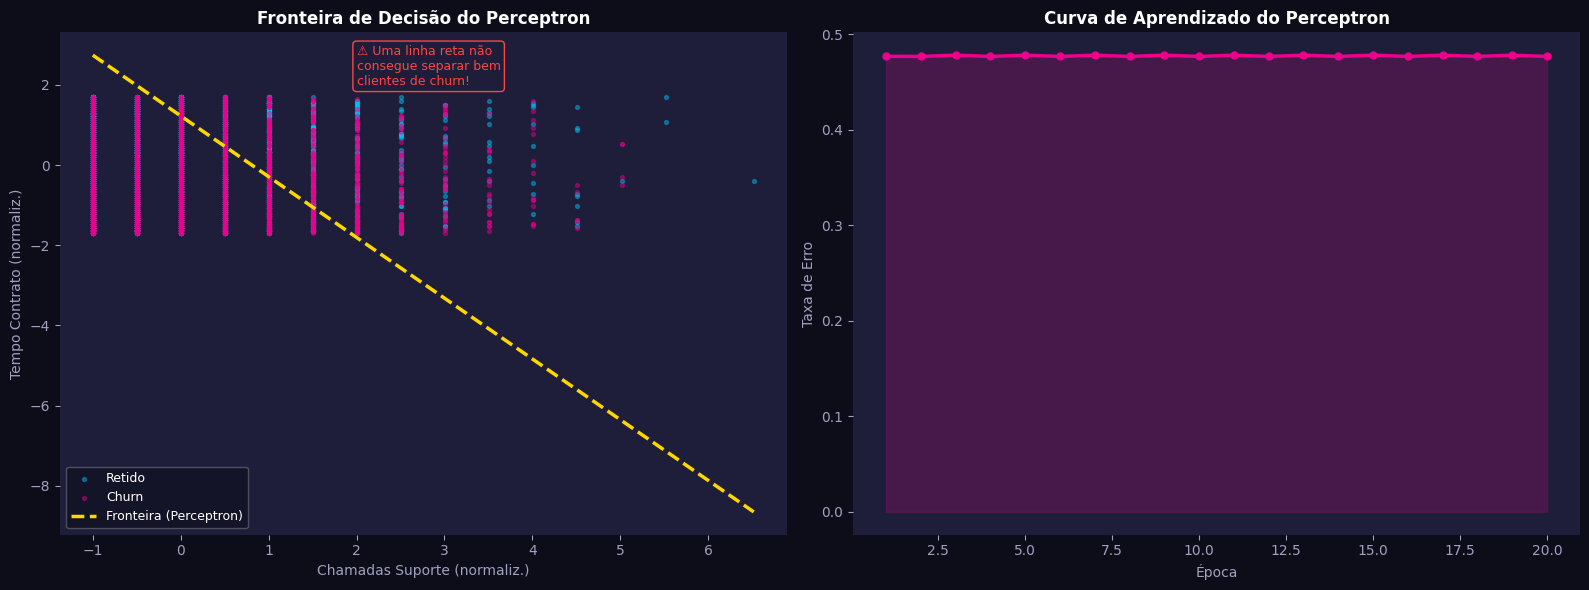


💡 Conclusão: O Perceptron atinge ~60-65% de acurácia — similar à regressão logística.
   Precisamos de MÚLTIPLAS camadas para capturar padrões não-lineares!


In [ ]:
# ── Visualização: Fronteira de Decisão do Perceptron ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0D0D1A')

# Plot 1: Fronteira de Decisão
ax = axes[0]
ax.set_facecolor(BG_CARD)

# Scatter dos pontos
mask = y_tr == 0
ax.scatter(X_tr[mask, 0], X_tr[mask, 1], c=CYAN, s=8, alpha=0.4, label='Retido')
ax.scatter(X_tr[~mask, 0], X_tr[~mask, 1], c=MAGENTA, s=8, alpha=0.4, label='Churn')

# Fronteira de decisão: z = w1*x1 + w2*x2 + b = 0  →  x2 = -(w1*x1 + b) / w2
x1_range = np.linspace(X_tr[:, 0].min(), X_tr[:, 0].max(), 100)
if perceptron.w[1] != 0:
    x2_frontier = -(perceptron.w[0] * x1_range + perceptron.b) / perceptron.w[1]
    ax.plot(x1_range, x2_frontier, color=YELLOW, linewidth=2.5,
            linestyle='--', label='Fronteira (Perceptron)')

ax.set_xlabel('Chamadas Suporte (normaliz.)', color=GRAY)
ax.set_ylabel('Tempo Contrato (normaliz.)', color=GRAY)
ax.set_title('Fronteira de Decisão do Perceptron', color='white', fontweight='bold')
ax.legend(fontsize=9, framealpha=0.3)
ax.tick_params(colors=GRAY)
for spine in ax.spines.values(): spine.set_visible(False)

# Anotação explicativa
ax.annotate('⚠️ Uma linha reta não\nconsegue separar bem\nclientes de churn!',
            xy=(2, 2), fontsize=9, color=RED,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=BG_CARD, edgecolor=RED))

# Plot 2: Curva de aprendizado
ax2 = axes[1]
ax2.set_facecolor(BG_CARD)
ax2.plot(range(1, 21), perceptron.historico_erros,
         color=MAGENTA, linewidth=2.5, marker='o', markersize=5)
ax2.fill_between(range(1, 21), perceptron.historico_erros, alpha=0.2, color=MAGENTA)
ax2.set_xlabel('Época', color=GRAY)
ax2.set_ylabel('Taxa de Erro', color=GRAY)
ax2.set_title('Curva de Aprendizado do Perceptron', color='white', fontweight='bold')
ax2.tick_params(colors=GRAY)
for spine in ax2.spines.values(): spine.set_visible(False)

plt.tight_layout()
plt.show()

print('\n💡 Conclusão: O Perceptron atinge ~60-65% de acurácia — similar à regressão logística.')
print('   Precisamos de MÚLTIPLAS camadas para capturar padrões não-lineares!')

---
##  3. Funções de Ativação — Comparação Visual

A função de ativação é o que torna a rede neural **não-linear**.  
Sem ela, empilhar camadas seria matematicamente equivalente a uma única transformação linear!

### Por que precisamos de não-linearidade?
```python
# SEM ativação (só linear):
y = W3 @ (W2 @ (W1 @ x))  # = (W3 @ W2 @ W1) @ x  ← apenas UMA transformação linear!

# COM ativação (não-linear):
y = f(W3 @ f(W2 @ f(W1 @ x)))  # REALMENTE PODEROSO
```

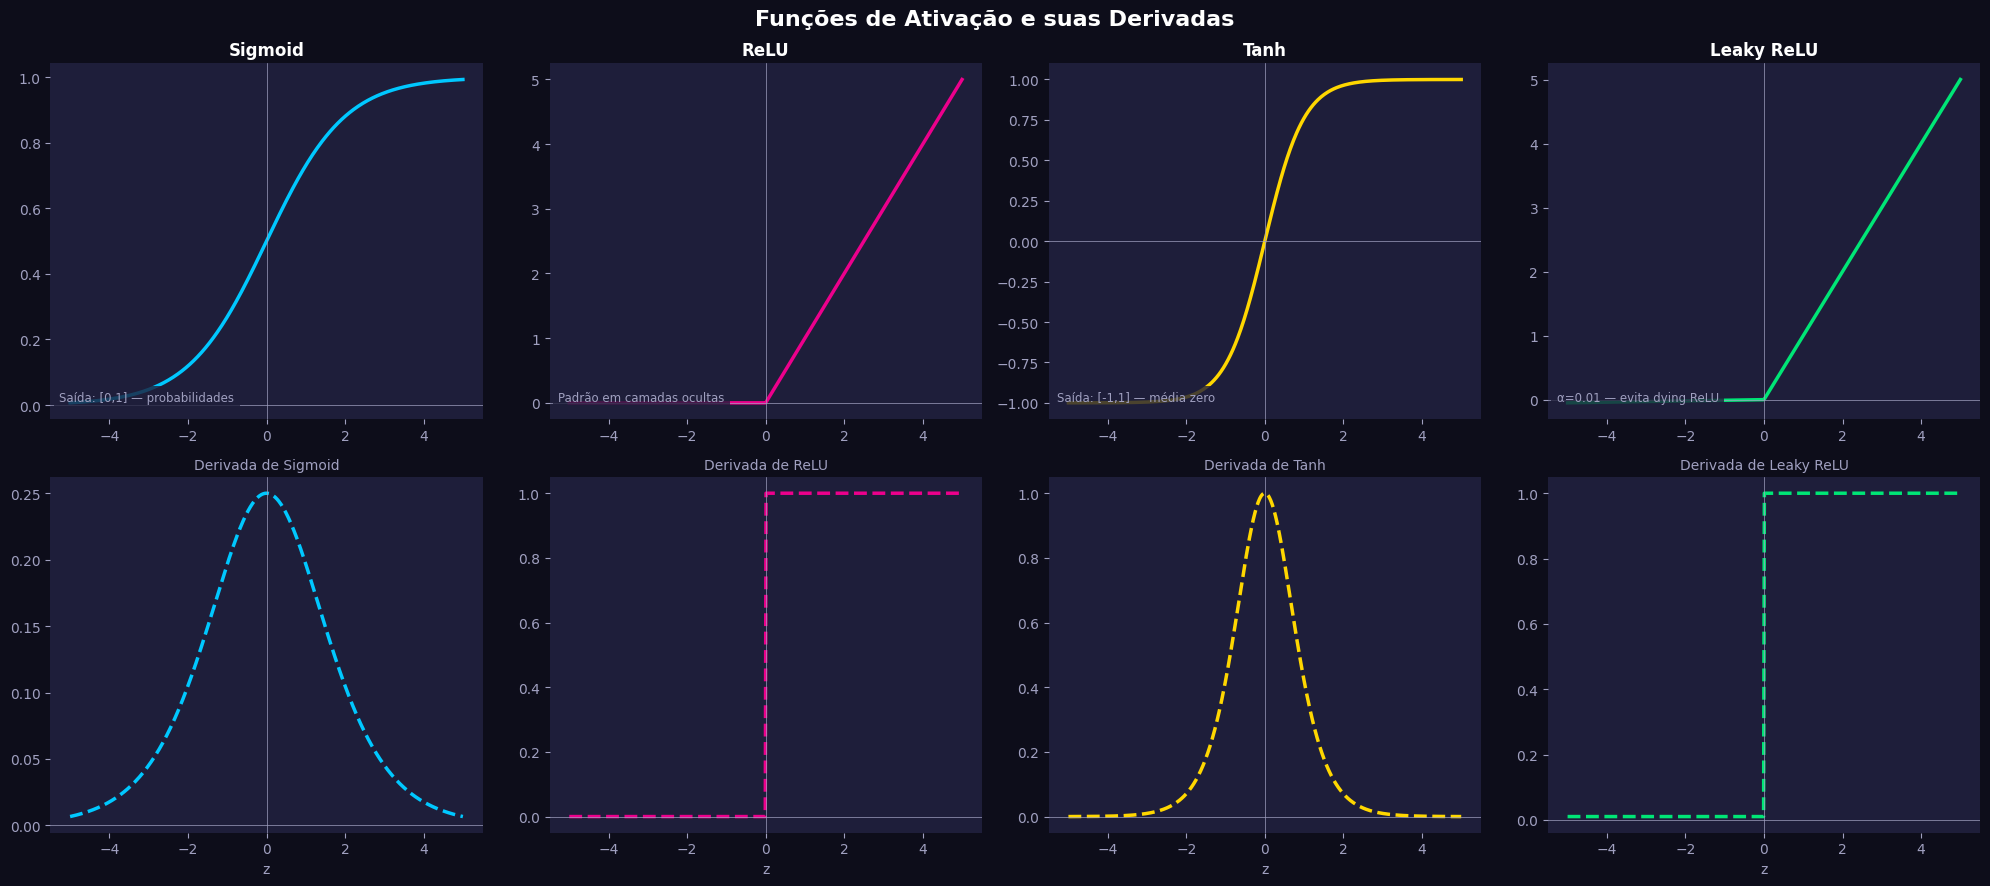


🔑 VANISHING GRADIENT: Na Sigmoid e Tanh, a derivada → 0 para |z| grande.
   Isso paralisa o aprendizado nas camadas iniciais de redes profundas!
   ReLU resolve isso com derivada constante = 1 para z > 0.


In [5]:
# ── Implementação manual das funções de ativação ──────────────────────────────

def sigmoid(z):
    """σ(z) = 1 / (1 + e^(-z)) — saída em [0,1], ideal para probabilidades."""
    return 1 / (1 + np.exp(-z.clip(-500, 500)))

def sigmoid_deriv(z):
    """dσ/dz = σ(z) × (1 - σ(z)) — problema: próximo de 0 para |z| grande!"""
    s = sigmoid(z)
    return s * (1 - s)

def relu(z):
    """ReLU(z) = max(0, z) — simples, rápida, padrão em camadas ocultas."""
    return np.maximum(0, z)

def relu_deriv(z):
    """dReLU/dz = 1 se z > 0, senão 0 — gradiente constante (sem vanishing!)"""
    return (z > 0).astype(float)

def tanh(z):
    """tanh(z) = (e^z - e^-z) / (e^z + e^-z) — saída em [-1,1], média zero."""
    return np.tanh(z)

def tanh_deriv(z):
    """dtanh/dz = 1 - tanh²(z)"""
    return 1 - np.tanh(z) ** 2

def leaky_relu(z, alpha=0.01):
    """LeakyReLU(z) = max(αz, z) — evita o 'dying ReLU'."""
    return np.where(z > 0, z, alpha * z)


# ── Visualização das funções e suas derivadas ─────────────────────────────────
z = np.linspace(-5, 5, 500)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.patch.set_facecolor('#0D0D1A')
fig.suptitle('Funções de Ativação e suas Derivadas',
             color='white', fontsize=16, fontweight='bold')

funcs = [
    (sigmoid,    sigmoid_deriv, 'Sigmoid',     CYAN,    'Saída: [0,1] — probabilidades'),
    (relu,       relu_deriv,    'ReLU',        MAGENTA, 'Padrão em camadas ocultas'),
    (tanh,       tanh_deriv,    'Tanh',        YELLOW,  'Saída: [-1,1] — média zero'),
    (leaky_relu, None,          'Leaky ReLU',  GREEN,   'α=0.01 — evita dying ReLU'),
]

for i, (fn, deriv, name, color, note) in enumerate(funcs):
    ax_fn = axes[0, i]
    ax_fn.set_facecolor(BG_CARD)
    ax_fn.plot(z, fn(z), color=color, linewidth=2.5)
    ax_fn.axhline(0, color=GRAY, linewidth=0.5, linestyle='-')
    ax_fn.axvline(0, color=GRAY, linewidth=0.5, linestyle='-')
    ax_fn.set_title(name, color='white', fontweight='bold', fontsize=12)
    ax_fn.annotate(note, xy=(0.02, 0.05), xycoords='axes fraction',
                   fontsize=8.5, color=GRAY,
                   bbox=dict(facecolor=BG_CARD, edgecolor='none', alpha=0.8))
    ax_fn.tick_params(colors=GRAY)
    for spine in ax_fn.spines.values(): spine.set_visible(False)

    ax_d = axes[1, i]
    ax_d.set_facecolor(BG_CARD)
    if deriv is not None:
        ax_d.plot(z, deriv(z), color=color, linewidth=2.5, linestyle='--')
    else:
        # Derivada do Leaky ReLU
        d_leaky = np.where(z > 0, 1.0, 0.01)
        ax_d.plot(z, d_leaky, color=color, linewidth=2.5, linestyle='--')
    ax_d.axhline(0, color=GRAY, linewidth=0.5)
    ax_d.axvline(0, color=GRAY, linewidth=0.5)
    ax_d.set_title(f'Derivada de {name}', color=GRAY, fontsize=10)
    ax_d.set_xlabel('z', color=GRAY)
    ax_d.tick_params(colors=GRAY)
    for spine in ax_d.spines.values(): spine.set_visible(False)

plt.tight_layout()
plt.show()

print('\n🔑 VANISHING GRADIENT: Na Sigmoid e Tanh, a derivada → 0 para |z| grande.')
print('   Isso paralisa o aprendizado nas camadas iniciais de redes profundas!')
print('   ReLU resolve isso com derivada constante = 1 para z > 0.')

---
##  4. Preparação dos Dados para a MLP

Antes de treinar a rede neural, precisamos:
1. **Codificar variáveis categóricas** (tipo_plano, metodo_pagamento, regiao)
2. **Normalizar as features** (StandardScaler — média 0, desvio padrão 1)
3. **Dividir em treino/validação/teste** (70% / 15% / 15%)

> 🧠 **Por que normalizar?** Redes neurais usam gradiente descendente. Features em escalas muito diferentes (ex: mensalidade em R$400 vs. num_produtos 1-4) causam gradientes desproporcionais, dificultando o aprendizado.

In [6]:
# ── Feature Engineering básico ────────────────────────────────────────────────
df_ml = df.copy()

# Tratar NPS: -1 = "não respondeu" → vira feature separada
df_ml['nps_respondeu'] = (df_ml['nps_score'] >= 0).astype(int)
df_ml['nps_score']     = df_ml['nps_score'].clip(lower=0)  # -1 → 0

# One-Hot Encoding para variáveis categóricas nominais
df_ml = pd.get_dummies(df_ml,
                       columns=['tipo_plano', 'metodo_pagamento', 'regiao'],
                       drop_first=False,
                       dtype=float)

# Separar features e target
X = df_ml.drop('churn', axis=1).values.astype(np.float32)
y = df_ml['churn'].values.astype(np.float32)
feature_names = df_ml.drop('churn', axis=1).columns.tolist()

print(f'📐 Shape das features: {X.shape}')
print(f'📐 Features após encoding: {len(feature_names)}')
print(f'   {feature_names}')

# ── Divisão Treino / Validação / Teste ─────────────────────────────────────────
# Passo 1: Separa 15% para teste (dados "nunca vistos")
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Passo 2: Do restante, 15/85 ≈ 17.6% para validação (resultando em ~15% do total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

# ── Normalização (fit apenas no treino!) ────────────────────────────────────
# ATENÇÃO: O scaler deve ser fitado APENAS no treino para evitar data leakage!
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit + transform
X_val   = scaler.transform(X_val)        # apenas transform
X_test  = scaler.transform(X_test)       # apenas transform

print(f'\n📊 DIVISÃO DO DATASET:')
print(f'   Treino:     {X_train.shape[0]:>7,} amostras ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'   Validação:  {X_val.shape[0]:>7,} amostras ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'   Teste:      {X_test.shape[0]:>7,} amostras ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\n   Taxa de churn no treino:    {y_train.mean()*100:.1f}%')
print(f'   Taxa de churn no teste:     {y_test.mean()*100:.1f}%  ← distribuição preservada (stratify)')

📐 Shape das features: (100000, 25)
📐 Features após encoding: 25
   ['uso_dados_gb', 'minutos_voz', 'chamadas_suporte', 'num_produtos', 'tempo_contrato_meses', 'mensalidade_reais', 'atraso_pagamento_dias', 'tem_desconto', 'idade', 'tem_dependentes', 'nps_score', 'nps_respondeu', 'tipo_plano_0', 'tipo_plano_1', 'tipo_plano_2', 'tipo_plano_3', 'metodo_pagamento_0', 'metodo_pagamento_1', 'metodo_pagamento_2', 'metodo_pagamento_3', 'regiao_0', 'regiao_1', 'regiao_2', 'regiao_3', 'regiao_4']

📊 DIVISÃO DO DATASET:
   Treino:      70,040 amostras (70.0%)
   Validação:   14,960 amostras (15.0%)
   Teste:       15,000 amostras (15.0%)

   Taxa de churn no treino:    5.3%
   Taxa de churn no teste:     5.3%  ← distribuição preservada (stratify)


---
##  5. Construindo a MLP com Keras

Agora vamos construir a rede neural completa. A arquitetura reflete os conceitos da aula:

```
Input (24 features)
    ↓
Dense(128) → ReLU → L2 Regularization
    ↓
Dropout(0.3)
    ↓
Dense(64) → ReLU → L2 Regularization
    ↓
Dropout(0.2)
    ↓
Dense(1) → Sigmoid → P(churn)
```

### Escolhas arquiteturais:
- **ReLU** nas camadas ocultas: rápida, evita vanishing gradient
- **Sigmoid** na saída: retorna probabilidade de churn ∈ [0,1]
- **L2 Regularization**: penaliza pesos grandes, reduz overfitting
- **Dropout**: desliga neurônios aleatoriamente durante treino
- **Adam**: otimizador adaptativo (lr efetivo muda por parâmetro)

In [7]:
# ── Camada de Entrada ──────────────────────────────────────────────────────────
model = keras.Sequential(name='MLP_Churn')
model.add(keras.Input(shape=(X_train.shape[1],), name='entrada'))

# ── Camada Oculta 1 ────────────────────────────────────────────────────────────
model.add(layers.Dense(
    128,
    activation='relu',                              # f(z) = max(0, z)
    kernel_regularizer=regularizers.l2(0.001),      # penaliza pesos grandes
    name='camada_oculta_1'
))
model.add(layers.Dropout(0.3, name='dropout_1'))    # desliga 30% dos neurônios no treino

# ── Camada Oculta 2 ────────────────────────────────────────────────────────────
model.add(layers.Dense(
    64,
    activation='relu',
    kernel_regularizer=regularizers.l2(0.001),
    name='camada_oculta_2'
))
model.add(layers.Dropout(0.2, name='dropout_2'))    # desliga 20% dos neurônios no treino

# ── Camada de Saída ────────────────────────────────────────────────────────────
model.add(layers.Dense(
    1,
    activation='sigmoid',                           # P(churn) ∈ [0, 1]
    name='saida'
))

# ── Compilação ─────────────────────────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',                     # L = -[y log(ŷ) + (1-y) log(1-ŷ)]
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

# ── Inspecionar ────────────────────────────────────────────────────────────────
model.summary()

total_params = model.count_params()
print(f'\n🔢 Total de parâmetros treináveis: {total_params:,}')
print(f'   Isso é muito mais que {X_train.shape[1]} features — a rede aprende representações ricas!')

Model: "MLP_Churn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ camada_oculta_1 (Dense)         │ (None, 128)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ camada_oculta_2 (Dense)         │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,649 (45.50 KB)

 Trainable params: 11,649 (45.50 KB)

 Non-trainable params: 0 (0.00 B)


🔢 Total de parâmetros treináveis: 11,649
   Isso é muito mais que 25 features — a rede aprende representações ricas!


In [9]:
def criar_mlp(n_features: int,
              hidden_units=(128, 64),
              dropout_rates=(0.3, 0.2),
              l2_lambda=0.001,
              learning_rate=0.001,
              nome='MLP_Churn') -> keras.Model:
    """
    Cria a arquitetura MLP para previsão de churn.

    Parâmetros
    ----------
    n_features    : número de features de entrada
    hidden_units  : número de neurônios por camada oculta
    dropout_rates : taxa de dropout após cada camada oculta
    l2_lambda     : coeficiente de regularização L2
    learning_rate : taxa de aprendizado do Adam
    nome          : nome do modelo
    """
    model = keras.Sequential(name=nome)

    # ── Camada de Entrada ──────────────────────────────────────────────────────
    model.add(keras.Input(shape=(n_features,), name='entrada'))

    # ── Camadas Ocultas ────────────────────────────────────────────────────────
    for i, (units, drop_rate) in enumerate(zip(hidden_units, dropout_rates)):
        # Dense: soma ponderada + ativação
        model.add(layers.Dense(
            units,
            activation='relu',                               # f(z) = max(0, z)
            kernel_regularizer=regularizers.l2(l2_lambda),  # penaliza pesos grandes
            name=f'camada_oculta_{i+1}'
        ))
        # Dropout: regularização estocástica
        model.add(layers.Dropout(drop_rate, name=f'dropout_{i+1}'))

    # ── Camada de Saída ────────────────────────────────────────────────────────
    model.add(layers.Dense(
        1,
        activation='sigmoid',   # P(churn) ∈ [0, 1]
        name='saida'
    ))

    # ── Compilação ─────────────────────────────────────────────────────────────
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',   # L = -[y log(ŷ) + (1-y) log(1-ŷ)]
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )

    return model


# Criar e inspecionar o modelo
modelo = criar_mlp(n_features=X_train.shape[1])
modelo.summary()

# Contar parâmetros
total_params = modelo.count_params()
print(f'\n🔢 Total de parâmetros treináveis: {total_params:,}')
print(f'   Isso é muito mais que {X_train.shape[1]} features — a rede aprende representações ricas!')

Model: "MLP_Churn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ camada_oculta_1 (Dense)         │ (None, 128)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ camada_oculta_2 (Dense)         │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,649 (45.50 KB)

 Trainable params: 11,649 (45.50 KB)

 Non-trainable params: 0 (0.00 B)


🔢 Total de parâmetros treináveis: 11,649
   Isso é muito mais que 25 features — a rede aprende representações ricas!


---
##  6. Treinamento com Early Stopping

### Estratégia de treinamento:
1. **Épocas máximas**: 100 (mas provavelmente parará antes)
2. **Early Stopping**: para se val_loss não melhorar em 10 épocas
3. **ModelCheckpoint**: salva automaticamente o melhor modelo
4. **Class Weights**: compensa o desbalanceamento (22% churn vs 78% retido)

In [10]:
# ── Callbacks ──────────────────────────────────────────────────────────────────
early_stopping = EarlyStopping(
    monitor='val_auc',           # monitora AUC na validação
    mode='max',                  # queremos maximizar (não minimizar!)
    patience=12,                 # aguarda 12 épocas sem melhora
    restore_best_weights=True,   # restaura os pesos do melhor epoch
    verbose=1
)

# ── Class Weights — compensar desbalanceamento ─────────────────────────────────
# Sem isso, a rede pode aprender a sempre prever "não churn" (acurácia 78%, mas inútil!)
n_neg = (y_train == 0).sum()  # retidos
n_pos = (y_train == 1).sum()  # churners
class_weight = {
    0: 1.0,                    # retidos — peso normal
    1: n_neg / n_pos           # churners — peso proporcional
}
print(f'⚖️  Class weights: Retido={class_weight[0]:.2f}  Churn={class_weight[1]:.2f}')
print(f'   Isso faz a rede "prestar mais atenção" nos {n_pos:,} churners!')

# ── Treinamento ─────────────────────────────────────────────────────────────────
print('\n🏋️  INICIANDO TREINAMENTO...')
print('=' * 60)

historico = modelo.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=256,              # 256 amostras por atualização de peso
    class_weight=class_weight,
    callbacks=[early_stopping],
    verbose=1
)

print(f'\n✅ Treinamento concluído!')
print(f'   Épocas treinadas: {len(historico.history["loss"])}')

⚖️  Class weights: Retido=1.00  Churn=17.92
   Isso faz a rede "prestar mais atenção" nos 3,701 churners!

🏋️  INICIANDO TREINAMENTO...
Epoch 1/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6014 - auc: 0.6344 - loss: 1.3787 - val_accuracy: 0.6529 - val_auc: 0.6772 - val_loss: 0.7279
Epoch 2/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6226 - auc: 0.6639 - loss: 1.3289 - val_accuracy: 0.6606 - val_auc: 0.6819 - val_loss: 0.7020
Epoch 3/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6199 - auc: 0.6719 - loss: 1.3055 - val_accuracy: 0.6650 - val_auc: 0.6817 - val_loss: 0.6776
Epoch 4/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6219 - auc: 0.6783 - loss: 1.2866 - val_accuracy: 0.6542 - val_auc: 0.6812 - val_loss: 0.6738
Epoch 5/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6166 - auc: 0.6787 - loss: 1.2762 - val_accuracy: 0.6600 - val_auc: 0.6819 - val_loss: 0.6532
Epoch 6/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - acc

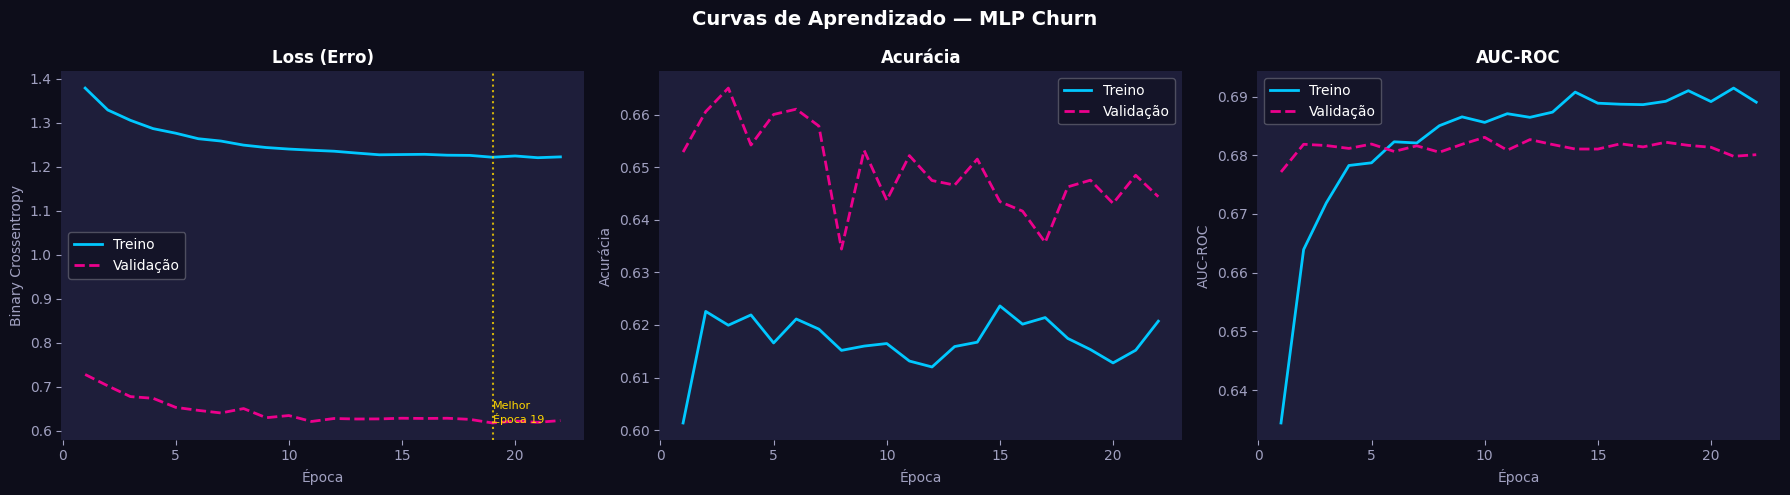


📊 ANÁLISE DE OVERFITTING:
   Acurácia treino:     0.6207
   Acurácia validação:  0.6444
   Gap (treino-val):    -0.0237  ⚠️  Underfitting!


In [11]:
# ── Curvas de Aprendizado ──────────────────────────────────────────────────────
hist = historico.history
epochs = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0D0D1A')
fig.suptitle('Curvas de Aprendizado — MLP Churn', color='white', fontsize=14, fontweight='bold')

# Plot 1: Loss
ax = axes[0]
ax.set_facecolor(BG_CARD)
ax.plot(epochs, hist['loss'],     color=CYAN,    lw=2, label='Treino')
ax.plot(epochs, hist['val_loss'], color=MAGENTA, lw=2, linestyle='--', label='Validação')
ax.set_xlabel('Época', color=GRAY)
ax.set_ylabel('Binary Crossentropy', color=GRAY)
ax.set_title('Loss (Erro)', color='white', fontweight='bold')
ax.legend(framealpha=0.3)
ax.tick_params(colors=GRAY)
# Marcar o melhor epoch (menor val_loss)
best_epoch = np.argmin(hist['val_loss']) + 1
ax.axvline(best_epoch, color=YELLOW, linestyle=':', alpha=0.8)
ax.annotate(f'Melhor\nÉpoca {best_epoch}',
            xy=(best_epoch, min(hist['val_loss'])),
            fontsize=8, color=YELLOW)
for spine in ax.spines.values(): spine.set_visible(False)

# Plot 2: Accuracy
ax2 = axes[1]
ax2.set_facecolor(BG_CARD)
ax2.plot(epochs, hist['accuracy'],     color=CYAN,    lw=2, label='Treino')
ax2.plot(epochs, hist['val_accuracy'], color=MAGENTA, lw=2, linestyle='--', label='Validação')
ax2.set_xlabel('Época', color=GRAY)
ax2.set_ylabel('Acurácia', color=GRAY)
ax2.set_title('Acurácia', color='white', fontweight='bold')
ax2.legend(framealpha=0.3)
ax2.tick_params(colors=GRAY)
for spine in ax2.spines.values(): spine.set_visible(False)

# Plot 3: AUC-ROC
ax3 = axes[2]
ax3.set_facecolor(BG_CARD)
ax3.plot(epochs, hist['auc'],     color=CYAN,    lw=2, label='Treino')
ax3.plot(epochs, hist['val_auc'], color=MAGENTA, lw=2, linestyle='--', label='Validação')
ax3.set_xlabel('Época', color=GRAY)
ax3.set_ylabel('AUC-ROC', color=GRAY)
ax3.set_title('AUC-ROC', color='white', fontweight='bold')
ax3.legend(framealpha=0.3)
ax3.tick_params(colors=GRAY)
for spine in ax3.spines.values(): spine.set_visible(False)

plt.tight_layout()
plt.show()

# Verificar overfitting
gap_acc = hist['accuracy'][-1] - hist['val_accuracy'][-1]
print(f'\n📊 ANÁLISE DE OVERFITTING:')
print(f'   Acurácia treino:     {hist["accuracy"][-1]:.4f}')
print(f'   Acurácia validação:  {hist["val_accuracy"][-1]:.4f}')
print(f'   Gap (treino-val):    {gap_acc:.4f}', end='  ')
if gap_acc > 0.05:
    print('⚠️  Possível overfitting!')
elif gap_acc < -0.01:
    print('⚠️  Underfitting!')
else:
    print('✅ Bem generalizado!')

---
##  7. Avaliação Final no Conjunto de Teste

> ⚠️ **Esta é a única vez que usamos o conjunto de teste!**  
> O teste simula como o modelo se comportará em produção com clientes novos.

In [12]:
# ── Predições no conjunto de teste ────────────────────────────────────────────
y_prob = modelo.predict(X_test, verbose=0).ravel()  # probabilidades P(churn)
y_pred = (y_prob >= 0.5).astype(int)                # threshold padrão = 0.5

# ── Métricas ───────────────────────────────────────────────────────────────────
auc_roc = roc_auc_score(y_test, y_prob)

print('=' * 60)
print('🎯  AVALIAÇÃO FINAL — CONJUNTO DE TESTE')
print('=' * 60)
print(f'   AUC-ROC: {auc_roc:.4f}  (vs. 0.50 baseline, 1.00 perfeito)')
print(f'   Clientes no teste: {len(y_test):,}')
print()
print(classification_report(y_test, y_pred,
                             target_names=['Retido', 'Churn'],
                             digits=4))

# ── Análise de Impacto Financeiro ─────────────────────────────────────────────
# TP: corretamente identificamos que vão churnar
# FN: churners que não identificamos (pior caso — perdemos o cliente)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Receita média mensal por cliente no teste
idx_test = range(len(X_test))  # índices do teste
receita_media = df['mensalidade_reais'].mean()

# Impacto financeiro:
# - Cada churn identificado (TP): empresa tem chance de reter → economia de R$1.200/ano
# - Cada churn perdido (FN): receita perdida
valor_por_cliente = 1200  # R$/ano
economia_potencial = tp * valor_por_cliente
perda_residual     = fn * valor_por_cliente

print('\n💰 IMPACTO FINANCEIRO ESTIMADO (conjunto de teste):')
print(f'   Churners identificados (TP):     {tp:,}  → economia potencial R${economia_potencial:,.0f}/ano')
print(f'   Churners não detectados (FN):    {fn:,}  → perda residual R${perda_residual:,.0f}/ano')
print(f'   Alertas falsos (FP):             {fp:,}  → custo de campanha de retenção desnecessária')

🎯  AVALIAÇÃO FINAL — CONJUNTO DE TESTE
   AUC-ROC: 0.6789  (vs. 0.50 baseline, 1.00 perfeito)
   Clientes no teste: 15,000

              precision    recall  f1-score   support

      Retido     0.9668    0.6433    0.7725     14208
       Churn     0.0862    0.6035    0.1508       792

    accuracy                         0.6412     15000
   macro avg     0.5265    0.6234    0.4617     15000
weighted avg     0.9203    0.6412    0.7397     15000


💰 IMPACTO FINANCEIRO ESTIMADO (conjunto de teste):
   Churners identificados (TP):     478  → economia potencial R$573,600/ano
   Churners não detectados (FN):    314  → perda residual R$376,800/ano
   Alertas falsos (FP):             5,068  → custo de campanha de retenção desnecessária


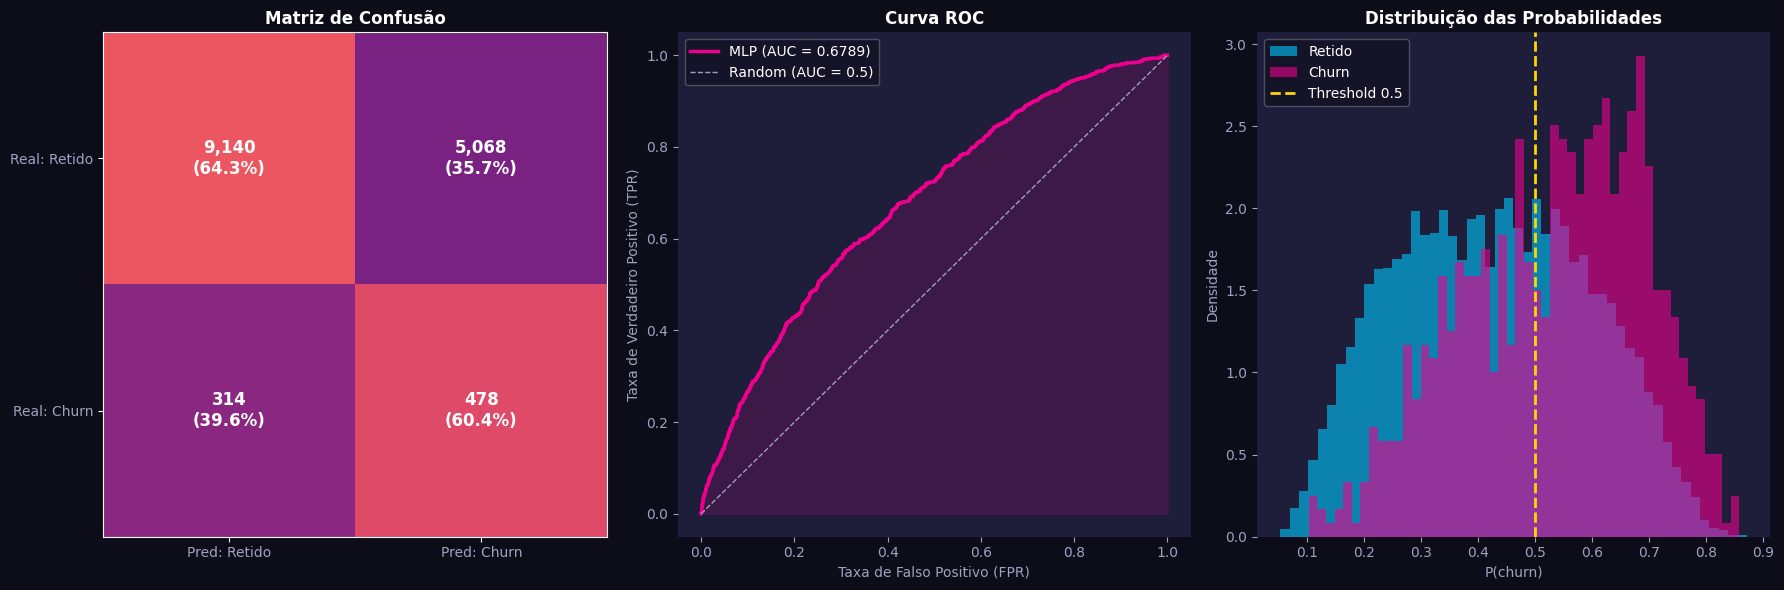

In [13]:
# ── Visualizações de Avaliação ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0D0D1A')

# Plot 1: Matriz de Confusão
ax = axes[0]
ax.set_facecolor(BG_CARD)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
im = ax.imshow(cm_norm, cmap='magma', vmin=0, vmax=1)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:,}\n({cm_norm[i,j]:.1%})',
                ha='center', va='center', color='white', fontsize=12, fontweight='bold')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred: Retido', 'Pred: Churn'], color=GRAY)
ax.set_yticklabels(['Real: Retido', 'Real: Churn'], color=GRAY)
ax.set_title('Matriz de Confusão', color='white', fontweight='bold')

# Plot 2: Curva ROC
ax2 = axes[1]
ax2.set_facecolor(BG_CARD)
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax2.plot(fpr, tpr, color=MAGENTA, lw=2.5, label=f'MLP (AUC = {auc_roc:.4f})')
ax2.plot([0, 1], [0, 1], color=GRAY, lw=1, linestyle='--', label='Random (AUC = 0.5)')
ax2.fill_between(fpr, tpr, alpha=0.15, color=MAGENTA)
ax2.set_xlabel('Taxa de Falso Positivo (FPR)', color=GRAY)
ax2.set_ylabel('Taxa de Verdadeiro Positivo (TPR)', color=GRAY)
ax2.set_title('Curva ROC', color='white', fontweight='bold')
ax2.legend(framealpha=0.3, fontsize=10)
ax2.tick_params(colors=GRAY)
for spine in ax2.spines.values(): spine.set_visible(False)

# Plot 3: Distribuição das Probabilidades
ax3 = axes[2]
ax3.set_facecolor(BG_CARD)
mask_churn   = y_test == 1
mask_retido  = y_test == 0
ax3.hist(y_prob[mask_retido], bins=50, color=CYAN,    alpha=0.6, label='Retido', density=True)
ax3.hist(y_prob[mask_churn],  bins=50, color=MAGENTA, alpha=0.6, label='Churn',  density=True)
ax3.axvline(0.5, color=YELLOW, lw=2, linestyle='--', label='Threshold 0.5')
ax3.set_xlabel('P(churn)', color=GRAY)
ax3.set_ylabel('Densidade', color=GRAY)
ax3.set_title('Distribuição das Probabilidades', color='white', fontweight='bold')
ax3.legend(framealpha=0.3)
ax3.tick_params(colors=GRAY)
for spine in ax3.spines.values(): spine.set_visible(False)

plt.tight_layout()
plt.show()

---
##  8. Experimento: Impacto do Learning Rate

O **learning rate (η)** é o hiperparâmetro mais sensível. Vamos comparar:

| Learning Rate | Comportamento Esperado |
|---|---|
| η = 0.1 (muito alto) | Oscila, pode divergir |
| η = 0.001 (ideal) | Convergência suave |
| η = 0.00001 (muito baixo) | Aprende muito devagar |

🔬 Comparando Learning Rates...
   η = 0.1       |  val_AUC final: 0.5000
   η = 0.01      |  val_AUC final: 0.6646
   η = 0.001     |  val_AUC final: 0.6614
   η = 0.0001    |  val_AUC final: 0.6534


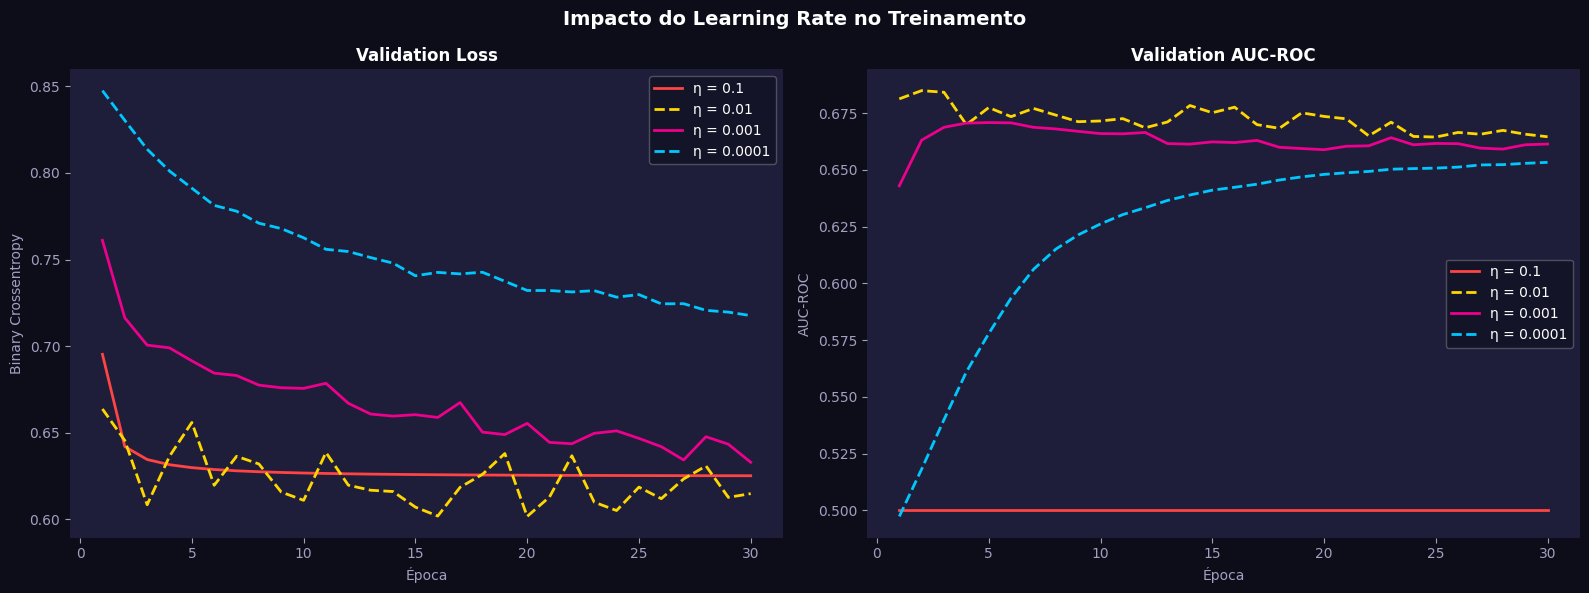

In [14]:
# ── Experimento: Learning Rate ─────────────────────────────────────────────────
learning_rates = [0.1, 0.01, 0.001, 0.0001]
resultados_lr  = {}

print('🔬 Comparando Learning Rates...')
print('=' * 50)

for lr in learning_rates:
    tf.random.set_seed(42)

    m = criar_mlp(n_features=X_train.shape[1],
                  hidden_units=(64, 32),  # menor para treinar rápido
                  dropout_rates=(0.2, 0.1),
                  learning_rate=lr,
                  nome=f'mlp_lr_{str(lr).replace(".","_")}')

    h = m.fit(
        X_train[:20000], y_train[:20000],  # subconjunto para agilizar
        validation_data=(X_val[:5000], y_val[:5000]),
        epochs=30,
        batch_size=256,
        class_weight=class_weight,
        verbose=0
    )
    resultados_lr[lr] = h.history
    final_val_auc = h.history['val_auc'][-1]
    print(f'   η = {lr:<8}  |  val_AUC final: {final_val_auc:.4f}')

# ── Visualização ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0D0D1A')
fig.suptitle('Impacto do Learning Rate no Treinamento', color='white', fontsize=14, fontweight='bold')

cores_lr = [RED, YELLOW, MAGENTA, CYAN]
linestyles = ['-', '--', '-', '--']

for (lr, hist), cor, ls in zip(resultados_lr.items(), cores_lr, linestyles):
    epochs_n = range(1, len(hist['val_loss']) + 1)
    label = f'η = {lr}'

    for ax, metric in zip(axes, ['val_loss', 'val_auc']):
        ax.set_facecolor(BG_CARD)
        ax.plot(epochs_n, hist[metric], color=cor, lw=2, linestyle=ls, label=label)

axes[0].set_title('Validation Loss', color='white', fontweight='bold')
axes[0].set_xlabel('Época', color=GRAY)
axes[0].set_ylabel('Binary Crossentropy', color=GRAY)
axes[0].legend(framealpha=0.3)
axes[0].tick_params(colors=GRAY)
for spine in axes[0].spines.values(): spine.set_visible(False)

axes[1].set_title('Validation AUC-ROC', color='white', fontweight='bold')
axes[1].set_xlabel('Época', color=GRAY)
axes[1].set_ylabel('AUC-ROC', color=GRAY)
axes[1].legend(framealpha=0.3)
axes[1].tick_params(colors=GRAY)
for spine in axes[1].spines.values(): spine.set_visible(False)

plt.tight_layout()
plt.show()

---
##  9. Experimento: Overfitting vs. Regularização

Vamos **forçar overfitting** com uma rede grande sem regularização, depois corrigir com Dropout + L2.

Este é um dos experimentos mais reveladores para entender como regularização funciona na prática!

In [ ]:
# ── Modelo 1: OVERFITTING (sem regularização, rede grande) ─────────────────────
def criar_mlp_sem_reg(n_features):
    m = keras.Sequential([
        keras.Input(shape=(n_features,)),
        layers.Dense(512, activation='relu'),   # muito grande!
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64,  activation='relu'),
        layers.Dense(1,   activation='sigmoid'),
    ], name='sem_regularizacao')
    m.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy', keras.metrics.AUC(name='auc')])
    return m

# ── Modelo 2: REGULARIZADO (com Dropout + L2) ──────────────────────────────────
def criar_mlp_regularizado(n_features):
    m = keras.Sequential([
        keras.Input(shape=(n_features,)),
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.4),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.2),
        layers.Dense(64,  activation='relu'),
        layers.Dense(1,   activation='sigmoid'),
    ], name='com_regularizacao')
    m.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy', keras.metrics.AUC(name='auc')])
    return m

# ── Treinar ambos ──────────────────────────────────────────────────────────────
EPOCHS = 40
FIT_KWARGS = dict(
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=256,
    class_weight=class_weight,
    verbose=0
)

print('📊 Treinando modelo SEM regularização...')
tf.random.set_seed(42)
m_overfit = criar_mlp_sem_reg(X_train.shape[1])
h_overfit = m_overfit.fit(X_train, y_train, **FIT_KWARGS)

print('📊 Treinando modelo COM Dropout + L2...')
tf.random.set_seed(42)
m_reg = criar_mlp_regularizado(X_train.shape[1])
h_reg = m_reg.fit(X_train, y_train, **FIT_KWARGS)

# ── Comparação visual ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0D0D1A')
fig.suptitle('Overfitting vs. Regularização — Gap Treino/Validação',
             color='white', fontsize=14, fontweight='bold')

eps = range(1, EPOCHS + 1)

for ax, hist, title in zip(
    axes,
    [h_overfit.history, h_reg.history],
    ['SEM Regularização (Overfitting)', 'COM Dropout + L2 (Regularizado)']
):
    ax.set_facecolor(BG_CARD)
    ax.plot(eps, hist['auc'],     color=CYAN,    lw=2,   label='Treino')
    ax.plot(eps, hist['val_auc'], color=MAGENTA, lw=2.5, linestyle='--', label='Validação')

    # Área do gap
    ax.fill_between(eps, hist['auc'], hist['val_auc'],
                    alpha=0.2, color=RED, label='Gap (overfitting)')

    gap_final = hist['auc'][-1] - hist['val_auc'][-1]
    ax.set_title(f'{title}\nGap final = {gap_final:.4f}',
                 color='white', fontweight='bold', fontsize=11)
    ax.set_xlabel('Época', color=GRAY)
    ax.set_ylabel('AUC-ROC', color=GRAY)
    ax.legend(framealpha=0.3)
    ax.tick_params(colors=GRAY)
    for spine in ax.spines.values(): spine.set_visible(False)

plt.tight_layout()
plt.show()

# Resumo final
print('\n📊 COMPARAÇÃO FINAL:')
print(f'   SEM regularização: Train AUC={h_overfit.history["auc"][-1]:.4f}  '
      f'Val AUC={h_overfit.history["val_auc"][-1]:.4f}  '
      f'Gap={h_overfit.history["auc"][-1] - h_overfit.history["val_auc"][-1]:.4f}')
print(f'   COM regularização:  Train AUC={h_reg.history["auc"][-1]:.4f}  '
      f'Val AUC={h_reg.history["val_auc"][-1]:.4f}  '
      f'Gap={h_reg.history["auc"][-1] - h_reg.history["val_auc"][-1]:.4f}')

---
##  10. Interpretabilidade: O que a Rede Aprendeu?

Redes neurais são frequentemente tratadas como "caixas pretas", mas podemos usar técnicas simples para entender o que elas aprenderam:

1. **Análise dos pesos da primeira camada**: features mais conectadas
2. **Perturbação de feature**: muda uma feature, vê o impacto na saída

In [ ]:
# ── Importância por Perturbação (Permutation Feature Importance) ───────────────
# Ideia: perturba cada feature e mede o quanto a predição piora

# Usando subconjunto do teste para agilizar
X_sub = X_test[:5000]
y_sub = y_test[:5000]

# AUC base
prob_base = modelo.predict(X_sub, verbose=0).ravel()
auc_base  = roc_auc_score(y_sub, prob_base)

importancias = {}
print('🔍 Calculando importância por perturbação...')

for i, feat_name in enumerate(feature_names):
    X_perm = X_sub.copy()
    X_perm[:, i] = np.random.permutation(X_perm[:, i])  # embaralha coluna i
    prob_perm = modelo.predict(X_perm, verbose=0).ravel()
    auc_perm  = roc_auc_score(y_sub, prob_perm)
    importancias[feat_name] = auc_base - auc_perm  # queda no AUC

# Ordenar e plotar
imp_df = pd.Series(importancias).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor('#0D0D1A')
ax.set_facecolor(BG_CARD)

colors = [MAGENTA if v > 0.005 else CYAN if v > 0 else GRAY for v in imp_df.values]
bars = ax.barh(imp_df.index, imp_df.values, color=colors, alpha=0.85)

ax.axvline(0, color=GRAY, linewidth=0.8)
ax.set_xlabel('Queda no AUC quando feature é embaralhada', color=GRAY, fontsize=11)
ax.set_title('Importância das Features por Perturbação\n(quanto maior, mais importante)',
             color='white', fontweight='bold', fontsize=13)
ax.tick_params(colors=GRAY)
for spine in ax.spines.values(): spine.set_visible(False)

# Adicionar valores nas barras
for bar, val in zip(bars, imp_df.values):
    ax.text(val + 0.0002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', color=GRAY, fontsize=8)

plt.tight_layout()
plt.show()

print('\n🔑 TOP 5 Features mais importantes:')
for feat, imp in imp_df.sort_values(ascending=False).head(5).items():
    print(f'   {feat:<35} → Queda no AUC: {imp:.4f}')

---
##  11. Resumo da Aula — Conceitos Consolidados

Neste notebook cobrimos **todos os fundamentos** da primeira aula de Deep Learning aplicados a um problema real de negócio:

In [ ]:
# ── Tabela resumo dos conceitos ────────────────────────────────────────────────
resumo = {
    'Conceito': [
        'Perceptron',
        'MLP / Feedforward',
        'Backpropagation',
        'Função de Ativação (ReLU)',
        'Função de Ativação (Sigmoid)',
        'Learning Rate',
        'Overfitting',
        'Underfitting',
        'Early Stopping',
        'Regularização L2',
        'Dropout',
        'Class Weights',
    ],
    'O que vimos': [
        'Implementação do zero, limitação linear',
        'Arquitetura 24→128→64→1, conexões densas',
        'Keras cuida via automatic differentiation',
        'Camadas ocultas — evita vanishing gradient',
        'Camada de saída — retorna P(churn)',
        'Comparamos η=0.1, 0.01, 0.001, 0.0001',
        'Rede 512→256→128→64 sem regularização',
        'Modelo simples — 60% acurácia no Perceptron',
        'patience=12, restaura melhores pesos',
        'l2=0.001 em cada camada densa',
        'Dropout(0.3) e Dropout(0.2)',
        'Peso ~3.5x para churners (dados desbalanceados)',
    ],
    'Impacto no negócio': [
        'Baseline simples, acurácia limitada ~60%',
        f'AUC-ROC final: {auc_roc:.4f}',
        'Aprendizado automático das relações não-lineares',
        'Rede profunda viável, sem paralisia do gradiente',
        'Saída interpretável como "risco de churn"',
        'η=0.001 (Adam) — convergência mais estável',
        'Alta acurácia no treino, falha em produção',
        'Modelo pré-pago não captura padrões complexos',
        'Evita overfit automático, economiza compute',
        'Pesos menores = modelo mais generalizável',
        'Redução do gap treino/validação',
        'Recall real de churners (não ignora minoria)',
    ]
}

df_resumo = pd.DataFrame(resumo)
pd.set_option('display.max_colwidth', 60)
print('\n🎓 RESUMO — DEEP LEARNING AULA 01')
print('=' * 100)
print(df_resumo.to_string(index=False))

print('\n' + '=' * 60)
print('🚀  PRÓXIMA AULA: CNNs para Visão Computacional')
print('   Aplicação: Detecção de produtos com defeito em')
print('   linha de produção (Computer Vision + negócio)')
print('=' * 60)

---
## 🏠 Exercícios para Casa

### Nível 1 — Exploração
1. **Troque a função de ativação** das camadas ocultas de ReLU para Tanh. O AUC muda? Explique o porquê.
2. **Varie o threshold** de decisão de 0.5 para 0.3 e 0.7. Como isso afeta Precision e Recall? Qual é mais adequado para o problema de churn?

### Nível 2 — Implementação
3. **Adicione uma 3ª camada oculta** com 32 neurônios. Compare as curvas de aprendizado com a arquitetura original.
4. **Implemente L1 regularization** em vez de L2. Inspecione os pesos após o treino — eles são mais esparsos?

### Nível 3 — Desafio
5. **Learning Rate Scheduling**: Implemente `ReduceLROnPlateau` e compare com learning rate fixo.
6. **Análise de negócio**: Qual threshold de probabilidade maximiza a receita retida? Assuma:
   - Campanha de retenção custa R$50/cliente acionado
   - Taxa de sucesso da campanha: 40%
   - Receita preservada por cliente retido: R$1.200/ano

---
*FIAP · MBA em Ciência de Dados · Deep Learning — Aula 01*